In [12]:
#중복된 피처명에 _1, _2  추가로 부여-> 새로운 피처명을 가지는 데프를 반환하는 함수 생성 
def get_new_feature_name_df(old_feature_name_df):
  feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                                                                       columns=['dup_cnt'])

  feature_dup_df = feature_dup_df.reset_index() #인덱스를 0부터 다시 매김. 
  new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
  new_feature_name_df['column_name'] = new_feature_name_df[['column_name',
                                                          'dup_cnt']].apply(lambda x : x.iloc[0]+'_'+str(x.iloc[1])
                                                            if x.iloc[1] > 0 else x.iloc[0], axis=1)

  new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
  return new_feature_name_df

In [13]:
#train 디렉터리의 학습용, test 디렉터리의 테스트용ㅇㅡㄹ 데이터프레임으로 로드 
#레이블의 칼럼: 'action' 
import pandas as pd

def get_human_dataset():
  #각 데이터파일은 공백으로 분리 -> sep='\s+' (=공백이 한개 이상 의미.)
  feature_name_df = pd.read_csv('./human_activity/features.txt', sep='\s+',
                                header=None, names=['column_index', 'column_name'])
  
  #중복된 피처명을 수정, 피처인덱스 drop하는 get_new_feature_name_df() 사용. - 신규피처명 데이터프레임 생성. 
  new_feature_name_df = get_new_feature_name_df(feature_name_df)

 # 학습 피처 데이터세트, 테스트 피처데이터를 Dataframe으로 로딩. 칼럼며은 feature_name 
  feature_name = new_feature_name_df.iloc[:, 1].values.tolist() #칼럼명을 리스트로 변경
  X_train = pd.read_csv('./human_activity/train/X_train.txt', sep='\s+', names=feature_name)
  X_test = pd.read_csv('./human_activity/test/X_test.txt', sep='\s+', names=feature_name)

# 학습 레이블 데이터세트, 테스트 레이블 데이터를 Dataframe으로 로딩. 칼럼며은 action 
  y_train = pd.read_csv('./human_activity/train/y_train.txt', header=None, names=['action'])
  y_test = pd.read_csv('./human_activity/test/y_test.txt', header=None, names=['action'])

  return X_train, X_test, y_train, y_test



In [14]:
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

X_train, X_test, y_train, y_test=get_human_dataset()

#GBM 수행 시간 측정을 위함. 시작 시간 설정.
start_time=time.time()

gb_clf=GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred= gb_clf.predict(X_test)
gb_accuracy=accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print('GBM 수행 시간: {0:.1f} 초'.format(time.time()-start_time))

c:\Users\0510n\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GBM 정확도: 0.9386
GBM 수행 시간: 871.3 초


In [10]:
import pandas as pd
print(pd.__version__)

3.0.3


In [2]:
import xgboost as xgb
from xgboost import XGBClassifier

In [3]:
import xgboost
print(xgboost.__version__)

3.4.1


In [ ]:
#위스콘신 유방암 데이터: 종양의 다양한 속성값을 기반으로 악성 , 양성 분류 
import xgboost as xgb
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset= load_breast_cancer()
features=dataset.data
labels= dataset.target #0: 악성, 1: 양성

cancer_df= pd.DataFrame(data=features, columns=dataset.feature_names) 
#feature_names : radius, texture 등등 
cancer_df['target']=labels #target 칼럼: labels로 넣음(악성, 양성 여부)
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [6]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [34]:
#80% 학습용 + 20% 테스트용
#학습용 중, 90%를 최종학습용+ 10% 검증용 

#cancer_df에서 feature 용 데이터프레임, label용 시리즈 객체 추출 
#맨마지막 칼럼이 label. 
X_features= cancer_df.iloc[:, :-1]
y_label= cancer_df.iloc[:, -1]

#전체 데이터 중 80% 학습용 + 20% 테스트용 분리 
X_train, X_test, y_train, y_test= train_test_split(X_features, y_label, test_size=0.2, random_state=156)

#위에서 만든 X_train, y_train을 다시 쪼개서, 90%를 최종학습용+ 10% 검증용  
X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

#최종학습용 409개, 검증용 46개, 테스트용 114개 = 총 569개

(455, 30) (114, 30)
(409, 30) (46, 30)


In [10]:
#학습, 검증, 테스트용 DMatrix 생성 
dtr= xgb.DMatrix(data=X_tr, label=y_tr)
dval=xgb.DMatrix(data=X_val, label=y_val)
dtest=xgb.DMatrix(data=X_test, label=y_test)



In [11]:
#XGBoost 하이퍼 파라미터 설정. 딕셔너리
params={'max_depth':3, 
        'eta': 0.05, 
        'objective':'binary:logistic', 
        'eval_metric':'logloss'
        }
num_rounds=400

In [ ]:
#학습 데이터 셋은 'train' 또는 평가 데이터 셋은 'eval'로 명기.
eval_list = [(dtr, 'train'), (dval, 'eval')] 
#또는 eval_list = [(dval, 'eval')] 만 명기해도 무방. 검증용만. 


#하이퍼 파라미터와 early stopping 파라미터를 train() 함수의 파라미터로 전달
xgb_model = xgb.train(params = params, dtrain = dtr, num_boost_round = num_rounds, \
                      early_stopping_rounds=50, evals = eval_list)

[0]	train-logloss:0.62473	eval-logloss:0.63225
[1]	train-logloss:0.58662	eval-logloss:0.60730
[2]	train-logloss:0.55210	eval-logloss:0.58562


[3]	train-logloss:0.52058	eval-logloss:0.56615
[4]	train-logloss:0.49155	eval-logloss:0.54542
[5]	train-logloss:0.46491	eval-logloss:0.53043
[6]	train-logloss:0.43969	eval-logloss:0.51101
[7]	train-logloss:0.41648	eval-logloss:0.49373
[8]	train-logloss:0.39503	eval-logloss:0.47735
[9]	train-logloss:0.37517	eval-logloss:0.46266
[10]	train-logloss:0.35673	eval-logloss:0.44940
[11]	train-logloss:0.33938	eval-logloss:0.43843
[12]	train-logloss:0.32276	eval-logloss:0.42597
[13]	train-logloss:0.30774	eval-logloss:0.41552
[14]	train-logloss:0.29356	eval-logloss:0.40645
[15]	train-logloss:0.27989	eval-logloss:0.39635
[16]	train-logloss:0.26709	eval-logloss:0.38696
[17]	train-logloss:0.25531	eval-logloss:0.37957
[18]	train-logloss:0.24381	eval-logloss:0.37218
[19]	train-logloss:0.23343	eval-logloss:0.36735
[20]	train-logloss:0.22322	eval-logloss:0.36096
[21]	train-logloss:0.21363	eval-logloss:0.35509
[22]	train-logloss:0.20499	eval-logloss:0.34939
[23]	train-logloss:0.19672	eval-logloss:0.34516

In [14]:
#학습이 완료됐으니, 테스트 데이터 세트로 예측 
pred_probs=xgb_model.predict(dtest)
print('predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs [:10],3))

# 예측 확률이 0.5보다 크면 1, 그렇지 않으면 0으로 예측값 결정하여 List 객체인 preds에 저장
preds = [ 1 if x > 0.5 else 0 for x in pred_probs]
print('예측값 10개만 표시:', preds[:10])

predict() 수행 결과값을 10개만 표시, 예측 확률 값으로 표시됨
[0.933 0.006 0.687 0.123 0.974 0.999 0.998 0.998 0.996 0.001]
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [19]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba = None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    # ROC-AUC 추가
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},F1:{3:.4f}. AUC: {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [20]:
get_clf_eval(y_test, preds, pred_probs)

오차행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도: 0.9740, 재현율: 0.9740,F1:0.9740. AUC: 0.9947


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

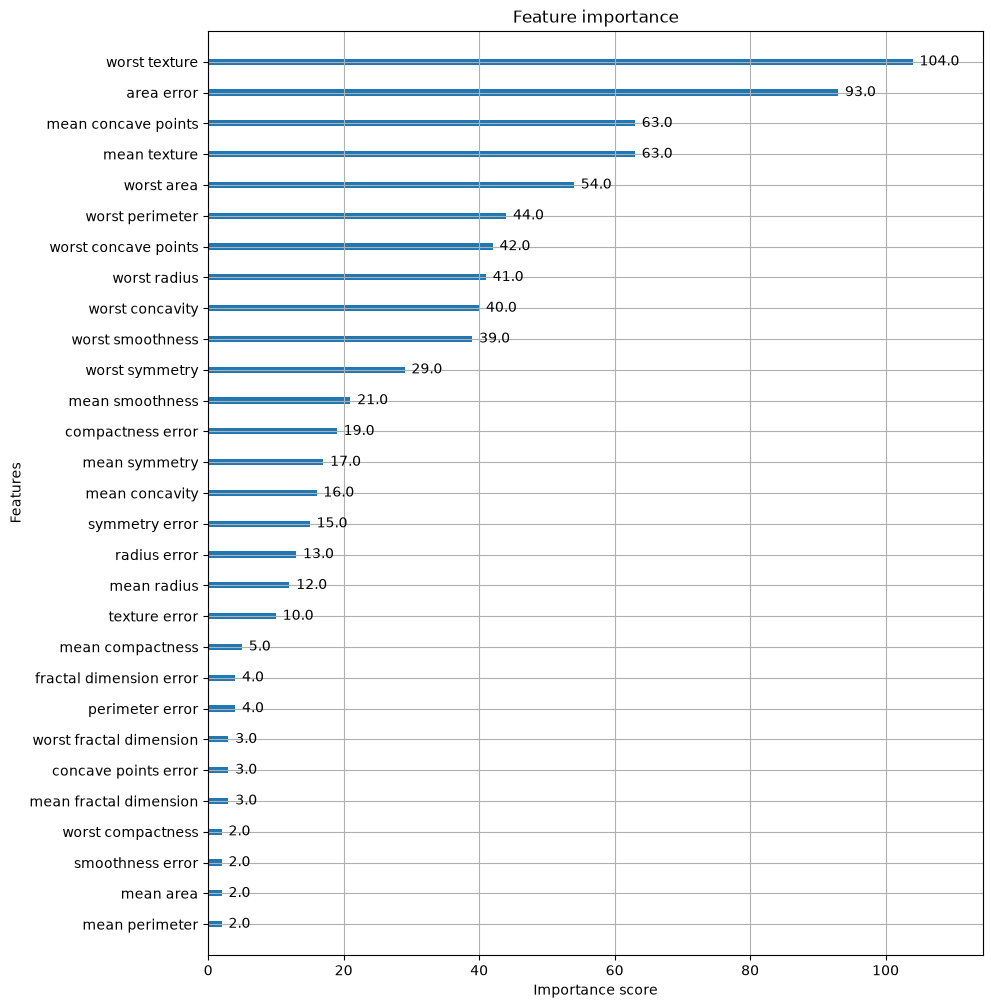

In [23]:
import matplotlib.pyplot as plt
from xgboost import plot_importance
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
plot_importance(xgb_model,ax=ax)

In [41]:
#사이킷런 래퍼 Xgboost 클래스인 XGBClassifier 임포트 
from xgboost import XGBClassifier

#Warning메시지를 없애기 위해 eval_metric 값을 XGBClassifier 생성 인자로 입력
xgb_wrapper= XGBClassifier(n_estimators=400,
                            learning_rate=0.05,
                            max_depth=3,
                            eval_metric='logloss')
xgb_wrapper.fit(X_train, y_train, verbose=True) # verbose=True : 중간 학습과정 출력 
w_preds= xgb_wrapper.predict(X_test)
w_pred_proba= xgb_wrapper.predict_proba(X_test)[:, 1] #benign(양성)일 확률. 




In [28]:
get_clf_eval(y_test, w_preds, w_pred_proba)

오차행렬
[[35  2]
 [ 1 76]]
정확도: 0.9737, 정밀도: 0.9744, 재현율: 0.9870,F1:0.9806. AUC: 0.9958


In [37]:
#조기중단 - 조기중단 관련한 파라미터를 fit 에 입력. 
#early_stopping_rounds, eval_metric, eval_set 
import xgboost as xgb
from xgboost import XGBClassifier
xgb_wrapper=XGBClassifier(n_estimators=400, 
                          learning_rate=0.05, 
                          max_depth=3, 
                          early_stopping_rounds= 50, 
                          eval_metric= "logloss" )
evals= [(X_tr, y_tr), (X_val, y_val)] #학습용 / 검증용으로 자동인식. (문자열 안넣어도o)
xgb_wrapper.fit(X_tr, y_tr , eval_set=evals,verbose=True) 
#fit 안에는 이번 학습에 실제로 사용할 데이터 입력. 학습 데이터, 검증용 데이터

ws50_preds=xgb_wrapper.predict(X_test)
ws50_pred_proba= xgb_wrapper.predict_proba(X_test)[:,1]



[0]	validation_0-logloss:0.62473	validation_1-logloss:0.63225
[1]	validation_0-logloss:0.58662	validation_1-logloss:0.60730
[2]	validation_0-logloss:0.55210	validation_1-logloss:0.58562
[3]	validation_0-logloss:0.52058	validation_1-logloss:0.56615
[4]	validation_0-logloss:0.49155	validation_1-logloss:0.54542
[5]	validation_0-logloss:0.46491	validation_1-logloss:0.53043
[6]	validation_0-logloss:0.43969	validation_1-logloss:0.51101
[7]	validation_0-logloss:0.41648	validation_1-logloss:0.49373
[8]	validation_0-logloss:0.39503	validation_1-logloss:0.47735
[9]	validation_0-logloss:0.37517	validation_1-logloss:0.46266
[10]	validation_0-logloss:0.35673	validation_1-logloss:0.44940
[11]	validation_0-logloss:0.33938	validation_1-logloss:0.43843
[12]	validation_0-logloss:0.32276	validation_1-logloss:0.42597
[13]	validation_0-logloss:0.30774	validation_1-logloss:0.41552
[14]	validation_0-logloss:0.29356	validation_1-logloss:0.40645
[15]	validation_0-logloss:0.27989	validation_1-logloss:0.39635
[1

In [38]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

오차행렬
[[35  2]
 [ 2 75]]
정확도: 0.9649, 정밀도: 0.9740, 재현율: 0.9740,F1:0.9740. AUC: 0.9947


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

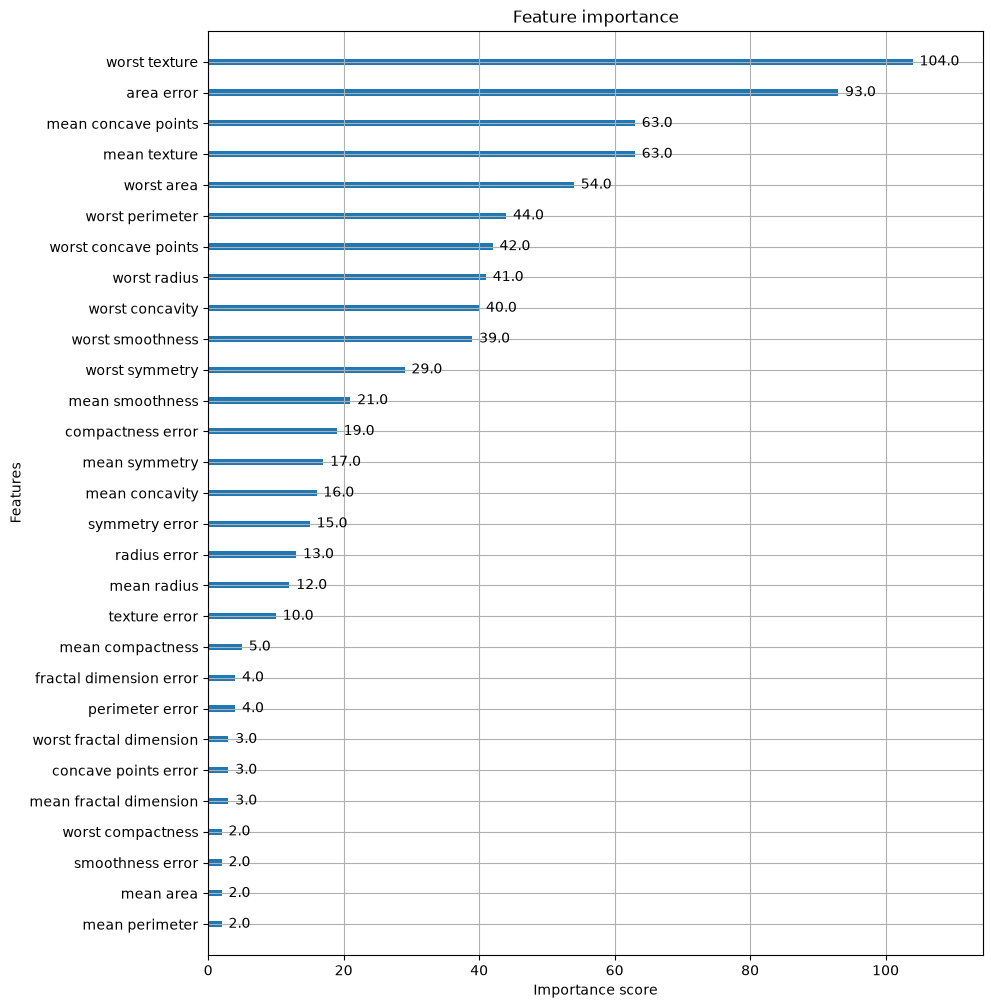

In [40]:
#plot_importance 모듈: 파이썬 래퍼 클래스와 똑같이 시각화결과도출 가능. 
import matplotlib.pyplot as plt
from xgboost import plot_importance
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
plot_importance(xgb_wrapper,ax=ax)


In [42]:
import lightgbm
from lightgbm import LGBMClassifier

In [46]:
#lightgbm으로 위스콘신 유방암 예측 
from lightgbm import LGBMClassifier

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

datset= load_breast_cancer()
cancer_df= pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target']= dataset.target
X_features= cancer_df.iloc[:, :-1]
y_label= cancer_df.iloc[:, -1]

#전체 데이터 증 80% 학습데이터 + 20% 테스트용 데이터 
#다시 쪼개서 90%는 학습, 10%는 검증용 데이터 
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label, test_size=0.2, random_state=156)
X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156)

#n_estimors=400 설정 
lgbm_wrapper= LGBMClassifier(n_estimators=400, learning_rate=0.05, 
                             early_stopping_rounds=50, eval_metric="logloss")
evals= [(X_tr, y_tr), (X_val, y_val)]
lgbm_wrapper.fit(X_tr, y_tr, eval_set= evals, verbose= True)
preds= lgbm_wrapper.predict(X_test)
pred_proba= lgbm_wrapper.predict_proba(X_test)[:, 1]


#평가 
get_clf_eval(y_test, preds, pred_proba)


[1]	training's binary_logloss: 0.625671	valid_1's binary_logloss: 0.628248
[2]	training's binary_logloss: 0.588173	valid_1's binary_logloss: 0.601106
[3]	training's binary_logloss: 0.554518	valid_1's binary_logloss: 0.577587
[4]	training's binary_logloss: 0.523972	valid_1's binary_logloss: 0.556324
[5]	training's binary_logloss: 0.49615	valid_1's binary_logloss: 0.537407
[6]	training's binary_logloss: 0.470108	valid_1's binary_logloss: 0.519401
[7]	training's binary_logloss: 0.446647	valid_1's binary_logloss: 0.502637
[8]	training's binary_logloss: 0.425055	valid_1's binary_logloss: 0.488311
[9]	training's binary_logloss: 0.405125	valid_1's binary_logloss: 0.474664
[10]	training's binary_logloss: 0.386526	valid_1's binary_logloss: 0.461267
[11]	training's binary_logloss: 0.367027	valid_1's binary_logloss: 0.444274
[12]	training's binary_logloss: 0.350713	valid_1's binary_logloss: 0.432755
[13]	training's binary_logloss: 0.334601	valid_1's binary_logloss: 0.421371
[14]	training's binary

<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

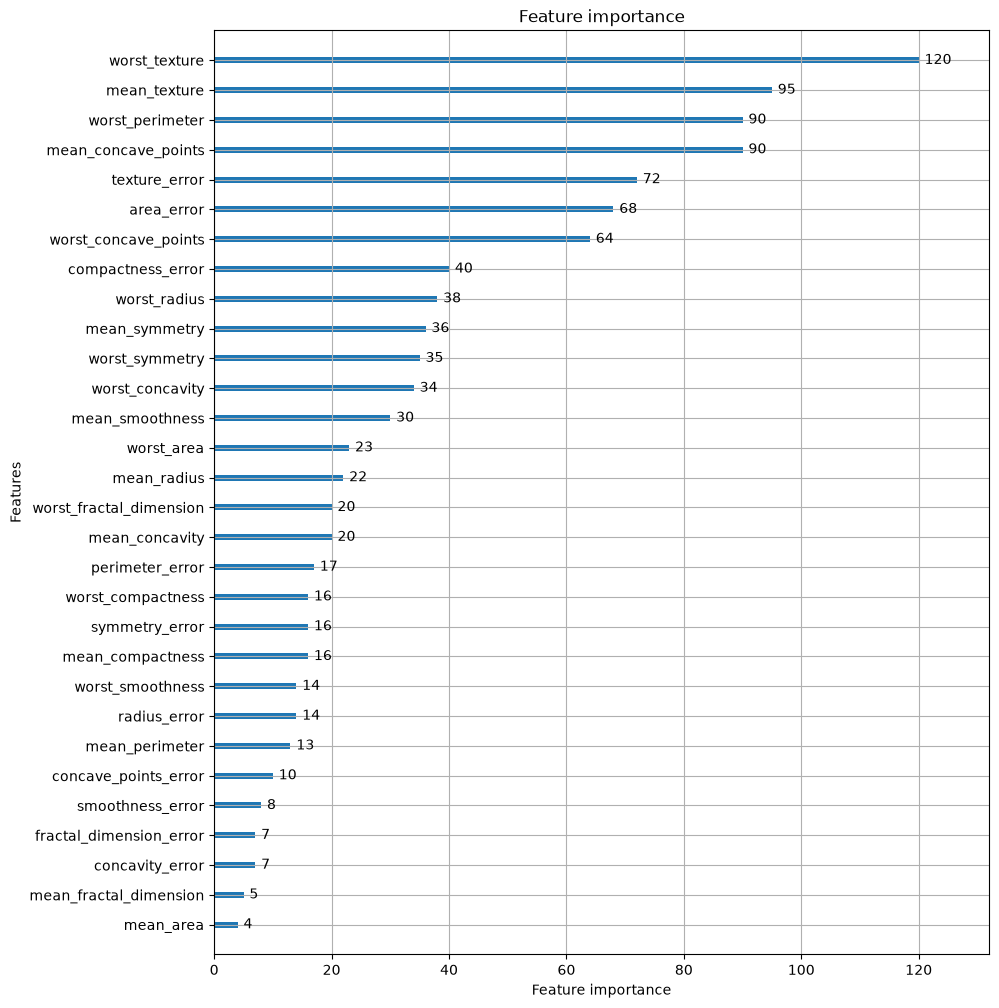

In [47]:
#시각화 
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax= plt.subplots(figsize=(10, 12))
plot_importance(lgbm_wrapper, ax=ax)

In [ ]:
params = {
    'max_depth' : [10, 20, 30, 40, 50], 'num_leaves': [35, 45, 55, 65],
    'colsample_bytree':[0.5, 0.6, 0.7, 0.8, 0.9], 'subsample': [0.5, 0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [10, 20, 30, 40], 'reg_alpha':[0.01, 0.05, 0.1]
}

In [50]:
from hyperopt import hp
search_space={'x':hp.quniform('x', -10, 10, 1) , 'y':hp.quniform('y', -15, 15, 1) }

In [51]:
from hyperopt import STATUS_OK

#목적 함수를 생성. 변숫값과 변수 검색공간을 가지는 딕셔너리를 인자로 받고, 특정값을 반환
def objective_func(search_space):
    x=search_space['x']
    y=search_space['y']
    retval= x**2-20*y

    return retval

In [53]:
from hyperopt import fmin, tpe, Trials
#입력 결괏값을 저장한 Trials 객체값 생성
trial_val= Trials()

#목적 함수의 최솟값을 반환하는 최적 입력 변숫값을 5번의 입력값 시도로 찾아냄. 
best_01= fmin(fn=objective_func, 
                  space=search_space, 
                  algo=tpe.suggest, 
                  max_evals=5, 
                  trials= trial_val, 
                  rstate= np.random.default_rng(seed=0))

print('best:', best_01)

100%|██████████| 5/5 [00:00<00:00, 431.32trial/s, best loss: -224.0]
best: {'x': np.float64(-4.0), 'y': np.float64(12.0)}


In [54]:
#max_evals 20회로 늘려서 재테스트
trial_val= Trials()

best_02= fmin(fn=objective_func, 
                  space=search_space, 
                  algo=tpe.suggest, 
                  max_evals=20, 
                  trials= trial_val, 
                  rstate= np.random.default_rng(seed=0))

print('best:', best_02)

100%|██████████| 20/20 [00:00<00:00, 524.19trial/s, best loss: -296.0]
best: {'x': np.float64(2.0), 'y': np.float64(15.0)}


In [55]:
import pandas as pd
#trial_val= Trials()


#reaults에서 loss 키값에 해당하는 밸류들을 추출하여 list로 생성 
losses= [loss_dict['loss'] for loss_dict in trial_val.results]

#데이터프레임 생성 
result_df= pd.DataFrame({'x':trial_val.vals['x'], 'y':trial_val.vals['x'], 'losses':losses}) #모두 밸류들이 리스트형태.
result_df

,x,y,losses
0,-6.0,-6.0,-64.0
1,-4.0,-4.0,-184.0
2,4.0,4.0,56.0
3,-4.0,-4.0,-224.0
4,9.0,9.0,61.0
5,2.0,2.0,-296.0
6,10.0,10.0,-40.0
7,-9.0,-9.0,281.0
8,-8.0,-8.0,64.0
9,-0.0,-0.0,100.0


In [56]:
X_train, X_test, y_train, y_test=train_test_split(X_features, y_label, test_size=0.2, random_state=156 )

X_tr, X_val, y_tr, y_val= train_test_split(X_train, y_train, test_size=0.1, random_state=156)

In [57]:
from hyperopt import hp
#검색공간 설정 

xgb_space={'max_depth': hp.quniform('max_depth', 5, 10, 1),
           'min_child_weight': hp.quniform('min_child_weight', 1, 2, 1),
            'learning_rate': hp.uniform('learning_rate', 0.01, 0.2),
            'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 1)}

In [62]:
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK
import numpy as np

#목적 함수 설정. (성능측정하는값, =정확도  반환)
def objective_func(search_space):
    xgb_clf= XGBClassifier(n_estimators=100, 
                           max_depth= int(search_space['max_depth']),
                           min_child_weight=int(search_space['min_child_weight']), 
                           learning_rate=search_space['learning_rate'],
                           colsample_bytree=search_space['colsample_bytree'],
                           eval_metric='logloss')
    accuracy= cross_val_score(xgb_clf, X_train, y_train, scoring='accuracy', cv=3)

    return {'loss':-1 * np.mean(accuracy), 'status': STATUS_OK} #딕셔너리 형태로 설정. 



In [64]:

from hyperopt import fmin, tpe, Trials

trial_val = Trials()
best = fmin(fn=objective_func,
  space=xgb_space,
  algo=tpe.suggest,
  max_evals=50,
  trials=trial_val, rstate=np.random.default_rng(seed=9))
print('best:', best)

100%|██████████| 50/50 [00:38<00:00,  1.31trial/s, best loss: -0.964868711513884] 
best: {'colsample_bytree': np.float64(0.6767849351713643), 'learning_rate': np.float64(0.11373887943384914), 'max_depth': np.float64(7.0), 'min_child_weight': np.float64(2.0)}


In [65]:
#도출된 최적의 하이퍼 파라미터를 직접 classifier 에 다시 넣깆 ㅓㄴ에, 형변환 후 확인 
print('colsample_bytree:{0}, learning_rate:{1}, max_depth:{2}, min_child_weight:{3}'.format(
    round(best['colsample_bytree'], 5), round(best['learning_rate'], 5),
    int(best['max_depth']), int(best['min_child_weight'])))

colsample_bytree:0.67678, learning_rate:0.11374, max_depth:7, min_child_weight:2


In [66]:
#도출된 최적의 하이퍼 파라미처를 이용해 XGBClassifier 재학습 -> 성능 평가 
xgb_wrapper = XGBClassifier(n_estimators=400,
learning_rate=round(best['learning_rate'], 5),
max_depth=int(best['max_depth']),
min_child_weight=int(best['min_child_weight']),
colsample_bytree=round(best['colsample_bytree'], 5)
, early_stopping_rounds=50, eval_metric='logloss')

evals = [(X_tr, y_tr), (X_val, y_val)]
xgb_wrapper.fit(X_tr, y_tr,
eval_set=evals, verbose=True)

preds = xgb_wrapper.predict(X_test)
pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, preds, pred_proba)

[0]	validation_0-logloss:0.57466	validation_1-logloss:0.59767
[1]	validation_0-logloss:0.50221	validation_1-logloss:0.54220
[2]	validation_0-logloss:0.44227	validation_1-logloss:0.50429
[3]	validation_0-logloss:0.39250	validation_1-logloss:0.47136
[4]	validation_0-logloss:0.34974	validation_1-logloss:0.44468
[5]	validation_0-logloss:0.31346	validation_1-logloss:0.42222
[6]	validation_0-logloss:0.28319	validation_1-logloss:0.39718
[7]	validation_0-logloss:0.25710	validation_1-logloss:0.37786
[8]	validation_0-logloss:0.23252	validation_1-logloss:0.36236
[9]	validation_0-logloss:0.21128	validation_1-logloss:0.34418
[10]	validation_0-logloss:0.19246	validation_1-logloss:0.33195
[11]	validation_0-logloss:0.17634	validation_1-logloss:0.32375
[12]	validation_0-logloss:0.16245	validation_1-logloss:0.31684
[13]	validation_0-logloss:0.15062	validation_1-logloss:0.30837
[14]	validation_0-logloss:0.13961	validation_1-logloss:0.30416
[15]	validation_0-logloss:0.12950	validation_1-logloss:0.29887
[1

**분류 실습 - 캐글 신용카드 사기 검출**

1. 데이터 일차 가공 및 모델 학습/예측/평가 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline
card_df = pd.read_csv('./creditcard.csv')
card_df.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


In [68]:
from sklearn.model_selection import train_test_split

#인자로 입력받은 DataFrame 복사한 뒤 Time 칼럼 삭제, 복사된 객체 반환 
def get_preprocessed_df(df=None):
    df_copy= df.copy()
    df_copy.drop('Time', axis=1, inplace=True)
    return df_copy

In [69]:
#사전 데이터 가공 후 학습/테스트 데이터 세트를 반환하는 함수 
def get_train_test_dataset(df=None):
    #인자로 입력된 df의 사전 데이터 가공이 완료된 복사 df 반화 
    df_copy= get_preprocessed_df(df)

    #df의 마지막 칼럼이 레이블, 나머지는 피처 
    X_features = df_copy.iloc[:, :-1]
    y_target = df_copy.iloc[:, -1]    

    #학습, 테스트 데이터 분할. stratify=y_target으로 Stratified 기반 분할 (y_target의 클래스 비율 유지)
    X_train, X_test, y_train, y_test = \
      train_test_split(X_features, y_target, test_size=0.3, random_state=0, stratify=y_target)

    #학습/테스트 세트 반환 
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test= get_train_test_dataset(card_df)


In [70]:
print('학습 데이터 레이블 값 비율')
print(y_train.value_counts()/y_train.shape[0] * 100)
print('테스트 데이터 레이블 값 비율')
print(y_test.value_counts()/y_test.shape[0] * 100)

학습 데이터 레이블 값 비율
Class
0    99.827451
1     0.172549
Name: count, dtype: float64
테스트 데이터 레이블 값 비율
Class
0    99.826785
1     0.173215
Name: count, dtype: float64


In [71]:
#로지슽틱 회귀로 신용카드사기여부 예측 
from sklearn.linear_model import LogisticRegression

lr_clf= LogisticRegression(max_iter=1000)
lr_clf.fit(X_train, y_train)
lr_pred= lr_clf.predict(X_test)
lr_pred_proba= lr_clf.predict_proba(X_test)[:, 1]

get_clf_eval(y_test, lr_pred, lr_pred_proba)


오차행렬
[[85281    14]
 [   57    91]]
정확도: 0.9992, 정밀도: 0.8667, 재현율: 0.6149,F1:0.7194. AUC: 0.9723


In [72]:
#인자로 Estimator ㄱ객체와 학습/테스트 데이터 세트를 입력받아 학습/예측/평가 수행 
def get_model_train_eval(model, ftr_train=None, ftr_test=None, tgt_train=None, tgt_test=None):
  model.fit(ftr_train, tgt_train)
  pred = model.predict(ftr_test)
  pred_proba = model.predict_proba(ftr_test)[:, 1]
  get_clf_eval(tgt_test, pred, pred_proba)

In [74]:
from lightgbm import LGBMClassifier

lgbm_clf= LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

오차행렬
[[85290     5]
 [   36   112]]
정확도: 0.9995, 정밀도: 0.9573, 재현율: 0.7568,F1:0.8453. AUC: 0.9790


2. 데이터 분포도 변환 후 모델 학습/예측/평가 

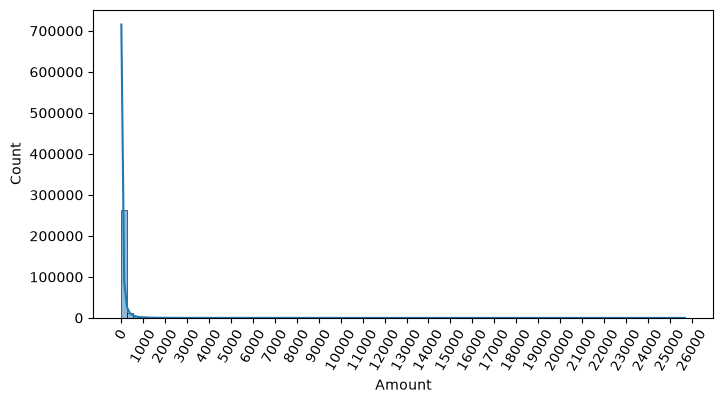

In [ ]:
#creditcard.csv의 중요 피처 값의 분포도 
import seaborn as sns

plt.figure(figsize=(8, 4))
plt.xticks(range(0, 30000, 1000), rotation=60)
sns.histplot(card_df['Amount'], bins=100, kde=True)
plt.show()

#Amount가 1000불 이하인 데이터가 대부분

In [77]:
#get_processed_df()fmf StandardScaler 클래스를 이용해 정규 분포 형태로 변환하는 코드로 변경 

from sklearn.preprocessing import StandardScaler

def get_preprocessed_df(df=None):
    df_copy= df.copy()
    scaler= StandardScaler()
    amount_n= scaler.fit_transform(df_copy['Amount'].values.reshape(-1,1))

    #변환된 Amount를 Amount_Scaled 로 피처명 변경 후 Df의 맨 앞 칼럼으로 입력 
    df_copy.insert(0, 'Amount_Scaled', amount_n)

    #기존 Tiem, Amount 피처 삭제 
    df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)
    return df_copy


In [ ]:
#Amount를 표준 정규 분포 형태로 변환 -> 로지스틱 회귀 및 LightBGM 수행 
X_train, X_test, y_train, y_test= get_train_test_dataset(card_df)

print("### 로지스틱 회귀 예측 성능 ###")
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

print("### LightBGM 예측 성능 ###")
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

#정규 분포로 Amount 변환 후, 로지스틱 회귀는 정밀도와 재현율 저하. LightGBM은 큰 변화X

### 로지스틱 회귀 예측 성능 ###
오차행렬
[[85281    14]
 [   55    93]]
정확도: 0.9992, 정밀도: 0.8692, 재현율: 0.6284,F1:0.7294. AUC: 0.9706
### LightBGM 예측 성능 ###
오차행렬
[[85290     5]
 [   37   111]]
정확도: 0.9995, 정밀도: 0.9569, 재현율: 0.7500,F1:0.8409. AUC: 0.9779


In [79]:
#로그 변환 
def get_preprocessed_df(df=None):
    df_copy= df.copy()
   
    #넘파이의 log1p()를 이용해 Amount를 로그 변환 
    amount_n= np.log1p(df_copy['Amount'])

    #변환된 Amount를 Amount_Scaled 로 피처명 변경 후 Df의 맨 앞 칼럼으로 입력 
    df_copy.insert(0, 'Amount_Scaled', amount_n)

    #기존 Tiem, Amount 피처 삭제 
    df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)
    return df_copy

In [ ]:
X_train, X_test, y_train, y_test= get_train_test_dataset(card_df)

print("### 로지스틱 회귀 예측 성능 ###")
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

print("### LightBGM 예측 성능 ###")
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

#로지스틱 회귀는 정밀도 향상 재현율 저하, LightGBM은 재현율 향상 
#로지스틱 회귀는 레이블이 극도로 불균일한 데이터인 경우, 데이터 변환 시 불안정한 성능을 보임. 

### 로지스틱 회귀 예측 성능 ###
오차행렬
[[85282    13]
 [   59    89]]
정확도: 0.9992, 정밀도: 0.8725, 재현율: 0.6014,F1:0.7120. AUC: 0.9734
### LightBGM 예측 성능 ###
오차행렬
[[85290     5]
 [   35   113]]
정확도: 0.9995, 정밀도: 0.9576, 재현율: 0.7635,F1:0.8496. AUC: 0.9796


3. 이상치 데이터 제거 후 모델 학습/예측/ 결과 


<Axes: >

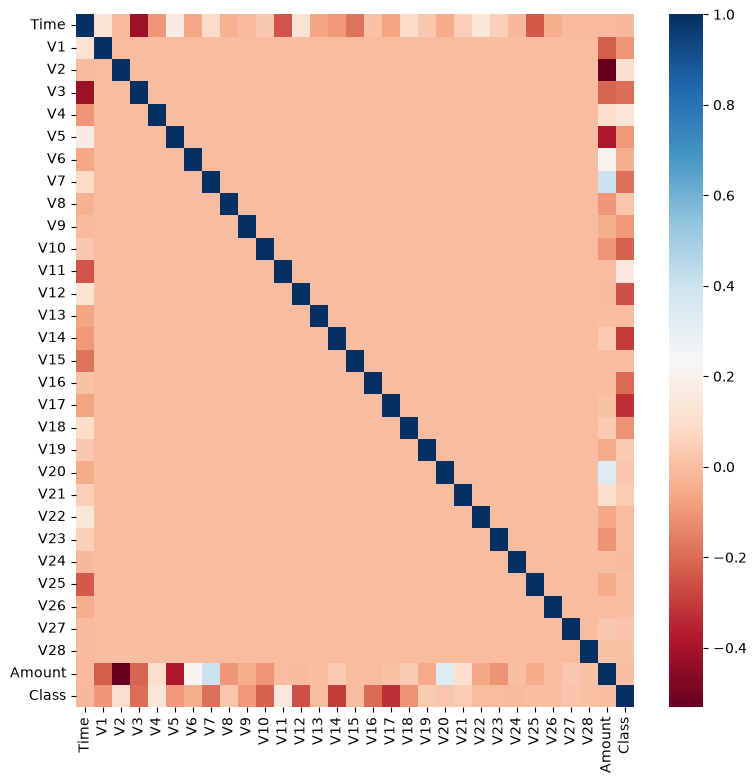

In [ ]:
#어떤 피터의 이상치 데이터를 검출?: 레이블과 가장 상관성이 높은 피처들
#DataFrame의 corr()을 이용해 각 피처별로 상관도를 구한 뒤 시본의 heatmap을 통해 시각화 

import seaborn as sns
plt.figure(figsize=(9,9))
corr= card_df.corr() #모든 변수들 사이 상관계수 계산 
sns.heatmap(corr, cmap='RdBu')

#v14, v17 선택(가장 진한 빨강)

In [85]:
import numpy as np 

#인자: df, 이상치를 검출한 칼럼 
def get_outlier(df=None, column=None, weight=1.5):
    #fraud 에 해당하는 column 데이터만 추출, 1/4분위와 3/4 분위 지점을 np.percentile로 구함.
    fraud= df[df['Class']==1][column]
    quantile_25 = np.percentile(fraud.values, 25)
    quantile_75 = np.percentile(fraud.values, 75)

    #IGR구하고, 1.5 곱해 최댓값, 최솟값 지점 구함. 
    iqr = quantile_75 - quantile_25
    iqr_weight = iqr * weight
    lowest_val = quantile_25 - iqr_weight
    highest_val = quantile_75 + iqr_weight

    #최댓값보다 크거나 최솟값보다 작은 값을 이상치데이처로 설정하고 DataFrame index 반환
    # .index : 행인덱스 반환  
    outlier_index= fraud[(fraud < lowest_val) | (fraud > highest_val)].index
    return outlier_index


In [86]:
outlier_index = get_outlier(df=card_df, column='V14', weight=1.5)
print('이상치 인덱스:', outlier_index)

이상치 인덱스: Index([8296, 8615, 9035, 9252], dtype='int64')


In [ ]:
#get_processed_df를 로그 변환 후 v14 피처의 이상치 데이터를 삭제하는 로직으로 변경 
def get_preprocessed_df(df=None):
    df_copy= df.copy()
    #넘파이의 log1p()를 이용해 Amount를 로그 변환 
    amount_n= np.log1p(df_copy['Amount'])
    #변환된 Amount를 Amount_Scaled 로 피처명 변경 후 Df의 맨 앞 칼럼으로 입력 
    df_copy.insert(0, 'Amount_Scaled', amount_n)
    #기존 Tiem, Amount 피처 삭제 
    df_copy.drop(['Time', 'Amount'], axis=1, inplace=True)

    #이상치 삭제하는 로직 추가 
    outlier_index = get_outlier(df=card_df, column='V14', weight=1.5)
    df_copy.drop(outlier_index, axis=0, inplace=True)

    return df_copy

X_train, X_test, y_train, y_test= get_train_test_dataset(card_df)

print("### 로지스틱 회귀 예측 성능 ###")
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

print("### LightBGM 예측 성능 ###")
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train, ftr_test=X_test, tgt_train=y_train, tgt_test=y_test)

#로지스틱 회귀, LightGBM 성능 크게 향상 

### 로지스틱 회귀 예측 성능 ###
오차행렬
[[85280    15]
 [   48    98]]
정확도: 0.9993, 정밀도: 0.8673, 재현율: 0.6712,F1:0.7568. AUC: 0.9725
### LightBGM 예측 성능 ###
오차행렬
[[85290     5]
 [   25   121]]
정확도: 0.9996, 정밀도: 0.9603, 재현율: 0.8288,F1:0.8897. AUC: 0.9780


4. SMOTE 오버 샘플링 적용 후 모델 학습/예측/평가 

In [88]:
from imblearn.over_sampling import SMOTE

smote= SMOTE(random_state=0)
X_train_over, y_train_over= smote.fit_resample(X_train, y_train)
print('SMOTE 적용 전 학습용 피처/레이블 데이터 세트: ', X_train.shape, y_train.shape)
print('SMOTE 적용 후 학습용 피처/레이블 데이터 세트: ', X_train_over.shape, y_train_over.shape)
print('SMOTE 적용 후 레이블 값 분포: \n', pd. Series (y_train_over).value_counts())

SMOTE 적용 전 학습용 피처/레이블 데이터 세트:  (199362, 29) (199362,)
SMOTE 적용 후 학습용 피처/레이블 데이터 세트:  (398040, 29) (398040,)
SMOTE 적용 후 레이블 값 분포: 
 Class
0    199020
1    199020
Name: count, dtype: int64


In [ ]:
lr_clf = LogisticRegression(max_iter=1000)
get_model_train_eval(lr_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)

#재현율은 크게 증가 .정밀도는 급격하게 저하. 

오차행렬
[[82933  2362]
 [   11   135]]
정확도: 0.9722, 정밀도: 0.0541, 재현율: 0.9247,F1:0.1022. AUC: 0.9736


In [92]:
from sklearn.metrics import precision_recall_curve

def precision_recall_curve_plot(y_test, pred_proba_c1):
  precisions, recalls, thresholds = precision_recall_curve( y_test, pred_proba_c1)

  plt.figure(figsize=(8, 6))
  threshold_boundary = thresholds.shape[0]
  plt.plot(thresholds, precisions[0:threshold_boundary], linestyle='--', label='precision')
  plt.plot(thresholds, recalls[0:threshold_boundary], label='recall')

  start, end = plt.xlim()
  plt.xticks(np.round(np.arange(start, end, 0.1), 2))

  plt.xlabel('Threshold value'); plt.ylabel('Precision and Recall value')
  plt.legend(); plt.grid()
  plt.show()

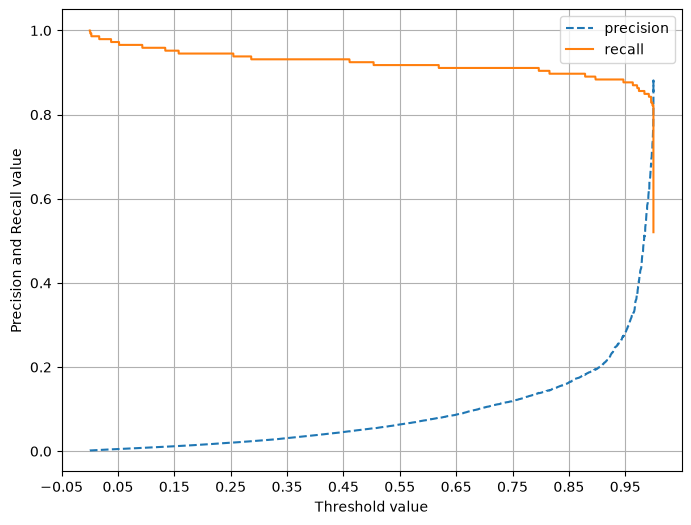

In [ ]:
precision_recall_curve_plot(y_test, lr_clf.predict_proba(X_test)[:,1])
#임곗값의 민감도가 매우 심함. 
#로지스틱 회귀모델은 SMOTE 적용 후 올바른 예측 모델이 아니게 됨. 

In [94]:
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=64, n_jobs=-1, boost_from_average=False)
get_model_train_eval(lgbm_clf, ftr_train=X_train_over, ftr_test=X_test, tgt_train=y_train_over, tgt_test=y_test)

오차행렬
[[85283    12]
 [   22   124]]
정확도: 0.9996, 정밀도: 0.9118, 재현율: 0.8493,F1:0.8794. AUC: 0.9814


In [99]:
import numpy as up

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer_data = load_breast_cancer()

X_data = cancer_data.data
y_label = cancer_data.target

X_train, X_test, y_train, y_test = train_test_split(X_data, y_label, test_size=0.2, random_state=0)

In [102]:
#개별 ML 모델 생성 
knn_clf= KNeighborsClassifier(n_neighbors=4)
rf_clf= RandomForestClassifier(n_estimators=100, random_state=0)
dt_clf= DecisionTreeClassifier()
ada_clf= AdaBoostClassifier(n_estimators=100)

#스태킹으로 만들어진 데이터 세트를 학습, 예측할 최종 모델 
lr_final= LogisticRegression()

In [103]:
#개별 모델들을 학습. 
knn_clf.fit(X_train, y_train)
rf_clf.fit(X_train, y_train)
dt_clf.fit(X_train, y_train)
ada_clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](100,)","[0.08,0.13,0.22,...,0.38,0.34,0.36]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[2.48,1.89,1.27,...,0.48,0.64,0.59]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...ate=924456017), DecisionTreeC...ate=535636817), DecisionTreeC...te=1581197258), DecisionTreeC...te=2080147244), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](30,)","[0. ,0.09,0. ,...,0.07,0.03,0.01]"


In [104]:
#학습된 개별 모델들의 각자 반환하는 예측 데이터 세트를 생성하고 개별 모델의 정확도 측정 
knn_pred = knn_clf.predict(X_test)
rf_pred = rf_clf.predict(X_test)
dt_pred = dt_clf.predict(X_test)
ada_pred = ada_clf.predict(X_test)
print('KNN 정확도: {0:4f}'.format(accuracy_score(y_test, knn_pred)))
print('랜덤 포레스트 정확도: {0:4f}'.format(accuracy_score(y_test, rf_pred)))
print('결정 트리 정확도: {0:24f}'.format(accuracy_score(y_test, dt_pred)))
print('에이다부스트 정확도: {0:4f}'.format(accuracy_score(y_test, ada_pred)))

KNN 정확도: 0.921053
랜덤 포레스트 정확도: 0.964912
결정 트리 정확도:                 0.903509
에이다부스트 정확도: 0.973684


In [105]:
#예측값들을 칼럼 레벨로 옆으로 붙여 피처값으로 만들기. 
pred= np.array([knn_pred, rf_pred, dt_pred, ada_pred])
print(pred.shape)

#transpose를 이용해 행과 열의위치 교환. 칼럼레벨로 각 알고리즘의 예측 결과를 피처로 만듦. 
pred= np.transpose(pred)
print(pred.shape)

(4, 114)
(114, 4)


In [ ]:
#최종 메타 모델인 로지스틱 회귀를 학습하고 예측 정확도 측정 
lr_final.fit(pred, y_test) #X_train 대신 pred
final= lr_final.predict(pred) #X_test 대신 pred 

print('최종 메타 모델의 예측 정확도: {0:4f}'.format(accuracy_score(y_test, final)))

최종 메타 모델의 예측 정확도: 0.973684


In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

#개별 기반 모델에서 최종 메타 모델이 사용할 학습 , 테스트용 데이터를 생성하기 위한 함수 
def get_stacking_base_datasets(model, X_train_n, y_train_n, X_test_n, n_folds):
    #지정된 n_folds 값으로 KFold 생성
    kf = KFold(n_splits=n_folds, shuffle=False)

    #추후에 메타 모델이 사용할 학습 데이터 반환을 위한 넘파이 배열 초기화 
    train_fold_pred= np.zeros((X_train_n.shape[0], 1)) #학습데이터
    test_pred = np.zeros((X_test_n.shape[0], n_folds)) #테스트 데이터 
    print(model.__class__.__name__, 'model 시작')

    #k폴드객체.split(X_train) -> (train_idx, valid_idx) k개 튜플 반환 
    for folder_counter, (train_index, valid_index) in enumerate(kf.split(X_train_n)):
        #입력된 학습 데이터에서 기반 모델이 학습/예측할 폴드 데이터 세트 추출 
        print('\t 폴드 세트:', folder_counter, '시작')
        X_tr= X_train_n[train_index]
        y_tr= y_train_n[train_index]
        X_te= X_train_n[valid_index]

        #폴드 세트 내부에서 다시 만들어진 학습 데이터로 기반 모델의 학습 수행 
        model.fit(X_tr, y_tr)

        #폴드 세트 내부에서 다시 만들어진 검증 데이터로 기반 모델 예측 후 데이터 저장 
        train_fold_pred[valid_index, :]= model.predict(X_te).reshape(-1, 1)

        #입력된 원본 테스트 데이터를 폴드 세트내 학습된 기반 모델에서 예측 후 데이터 저장
        test_pred[:, folder_counter] = model.predict(X_test_n)

    
    #폴드 세트 내에서 원본 테스트 데이터를 예측한 데이터를 평균하여 테스트 데이터로 생성
    test_pred_mean= np.mean(test_pred, axis=1).reshape(-1, 1) #최종 테스트 데이터 

    #train_fild_pred는 최종 메타 모델이 사용하는 학습 데이터, test_pred_mean은 테스트 데이터 
    return train_fold_pred, test_pred_mean




In [108]:
knn_train, knn_test = get_stacking_base_datasets(knn_clf, X_train, y_train, X_test, 7)
rf_train, rf_test = get_stacking_base_datasets(rf_clf, X_train, y_train, X_test, 7)
dt_train, dt_test = get_stacking_base_datasets(dt_clf, X_train, y_train, X_test, 7)
ada_train, ada_test = get_stacking_base_datasets(ada_clf, X_train, y_train, X_test, 7)

KNeighborsClassifier model 시작
	 폴드 세트: 0 시작
	 폴드 세트: 1 시작
	 폴드 세트: 2 시작
	 폴드 세트: 3 시작
	 폴드 세트: 4 시작
	 폴드 세트: 5 시작
	 폴드 세트: 6 시작
RandomForestClassifier model 시작
	 폴드 세트: 0 시작
	 폴드 세트: 1 시작
	 폴드 세트: 2 시작
	 폴드 세트: 3 시작
	 폴드 세트: 4 시작
	 폴드 세트: 5 시작
	 폴드 세트: 6 시작
DecisionTreeClassifier model 시작
	 폴드 세트: 0 시작
	 폴드 세트: 1 시작
	 폴드 세트: 2 시작
	 폴드 세트: 3 시작
	 폴드 세트: 4 시작
	 폴드 세트: 5 시작
	 폴드 세트: 6 시작
AdaBoostClassifier model 시작
	 폴드 세트: 0 시작
	 폴드 세트: 1 시작
	 폴드 세트: 2 시작
	 폴드 세트: 3 시작
	 폴드 세트: 4 시작
	 폴드 세트: 5 시작
	 폴드 세트: 6 시작


In [110]:
Stack_final_X_train = np.concatenate((knn_train, rf_train, dt_train, ada_train), axis=1)
#axis=1이므로 열 방향으로 붙임. = 최종 학습 데이터 
Stack_final_X_test = np.concatenate((knn_test, rf_test, dt_test, ada_test), axis=1)
#axis=1이므로 열 방향으로 붙임. = 최종 테스트 데이터 
print('원본 학습 피처 데이터 Shape:', X_train.shape, '원본 테스트 피처 Shape:', X_test.shape)
print('스태킹 학습 피처 데이터 Shape:', Stack_final_X_train.shape,
'스태킹 테스트 피처 데이터 Shape:', Stack_final_X_test.shape)

원본 학습 피처 데이터 Shape: (455, 30) 원본 테스트 피처 Shape: (114, 30)
스태킹 학습 피처 데이터 Shape: (455, 4) 스태킹 테스트 피처 데이터 Shape: (114, 4)


In [111]:
lr_final.fit(Stack_final_X_train, y_train)
stack_final = lr_final.predict(Stack_final_X_test)
print('최종 메타 모델의 예측 정확도: {0:4f}'.format(accuracy_score(y_test, stack_final)))

최종 메타 모델의 예측 정확도: 0.973684
